# Notebook 1: Feature Analysis & Model Benchmarks

## Purpose
This is the **entry-point exploration notebook**. It reads the original ACLED pipeline
output, engineers 9 new predictive features grounded in cross-variable analysis, and
benchmarks 5 model architectures on two feature sets (Main vs Enhanced).

## Datasets
| Dataset | Path | Description |
|---------|------|-------------|
| Input | `data/processed/model_data.csv` | Original ACLED pipeline output — 31 predictors, 3 targets, ~278k rows |
| Output | `data/processed/enhanced_data.csv` | Same + 9 engineered features (40 predictors total) |

## Targets
Three ACLED violence types: **Battles**, **Explosions/Remote violence**, **Violence against civilians**

## Models compared
| Model | Why included |
|-------|-------------|
| Random Forest | Project baseline — robust, interpretable importances |
| Gradient Boosting | sklearn GBR — boosting as a cross-check |
| XGBoost | Strong tabular competitor |
| LGBM Poisson | Count-data loss; handles discrete zeros |
| **LGBM Tweedie (p=1.5)** | **CAST methodology** — compound Poisson-Gamma designed for zero-inflated heavy-tailed counts |

## What this notebook does
1. **Feature analysis** — Spearman correlations, target distributions, cross-lag heatmap
2. **Engineers 9 features** — lag-2s, organized_violence, rolling averages, interaction term
   (logic lives in `utils/data_cleaning.build_enhanced_features()`)
3. **Benchmarks all 5 models** on Main (31 feats) and Enhanced (40 feats) datasets
4. Shows feature importances from LGBM Tweedie to validate the engineered features

**Test protocol:** top-10 most active regions · last 6 months held out · 3 targets
(10 × 6 months × 3 = 30 test sequences per model per dataset)


In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))   # project root → finds config/ and utils/
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from config import settings
from utils.risk_merge import RiskIndicatorMerger

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')

FIGURES = '../outputs/figures'
os.makedirs(FIGURES, exist_ok=True)

MAIN_PATH = '../data/processed/model_data.csv'
TARGETS   = settings.targets   # Battles | Explosions/Remote violence | Violence against civilians
SHORT     = {
    'Battles':                     'Battles',
    'Explosions/Remote violence':  'Remote Viol.',
    'Violence against civilians':  'VaC',
}

main_df = pd.read_csv(MAIN_PATH)
main_df['month_year'] = pd.to_datetime(main_df['month_year'])

print(f'main_df shape    : {main_df.shape}')
print(f'Predictors       : {len(settings.predictors)}')
print(f'Targets          : {TARGETS}')
print(f'Date range       : {main_df["month_year"].min().date()} → {main_df["month_year"].max().date()}')
print(f'Regions          : {main_df["matched_admin1_id"].nunique():,}')


main_df shape    : (278820, 36)
Predictors       : 31
Targets          : ['Battles', 'Explosions/Remote violence', 'Violence against civilians']
Date range       : 2018-01-01 → 2025-06-01
Regions          : 3,097


In [2]:
from utils.data_cleaning import build_enhanced_features

# ── Column references ────────────────────────────────────────────────────────
B1 = 'Battles (t-1)'
E1 = 'Explosions/Remote violence (t-1)'
V1 = 'Violence against civilians (t-1)'

NEW_FEATURES = [
    # a) Lag-2 — slow decay in autocorrelation (lag-2 r ≈ 0.70) justifies going deeper
    'Battles (t-2)',
    'Explosions/Remote violence (t-2)',
    'Violence against civilians (t-2)',
    # b) Aggregate signal — CAST's own target, captures combined threat level
    'organized_violence (t-1)',
    # c) Binary activity flag — helps model split zero-inflation from true low-activity
    'is_active (t-1)',
    # d) Multiplicative interaction — co-escalation table shows 13× jump in remote when Battles > 3
    'battles_x_remote (t-1)',
    # e) Rolling 3-month average — smoother trend, less sensitive to single-month spikes
    'Battles_3mo_avg (t-1)',
    'Remote_3mo_avg (t-1)',
    'VaC_3mo_avg (t-1)',
]

# build_enhanced_features() is defined in utils/data_cleaning.py and is the
# canonical implementation. This notebook uses it directly rather than
# maintaining a local copy, so any fix in the utils module applies here too.
enhanced_df    = build_enhanced_features(main_df)
ENHANCED_PREDS = settings.predictors + NEW_FEATURES

# Save enhanced dataset
enhanced_df.to_csv('../data/processed/enhanced_data.csv', index=False)

print(f'Main dataset     : {main_df.shape}     —  {len(settings.predictors)} predictors')
print(f'Enhanced dataset : {enhanced_df.shape}  —  {len(ENHANCED_PREDS)} predictors  (+{len(NEW_FEATURES)} new)')
print()
print('New features added:')
for f in NEW_FEATURES:
    print(f'  {f}')
print()
print('Saved → ../data/processed/enhanced_data.csv')


Main dataset     : (278820, 36)     —  31 predictors
Enhanced dataset : (278820, 45)  —  40 predictors  (+9 new)

New features added:
  Battles (t-2)
  Explosions/Remote violence (t-2)
  Violence against civilians (t-2)
  organized_violence (t-1)
  is_active (t-1)
  battles_x_remote (t-1)
  Battles_3mo_avg (t-1)
  Remote_3mo_avg (t-1)
  VaC_3mo_avg (t-1)

Saved → ../data/processed/enhanced_data.csv


## 1. Feature Analysis

Visualising the relationships that motivated the new features:
- Which features correlate most strongly with each target?
- How extreme is the zero-inflation that motivates Tweedie/Poisson loss?
- Cross-lag structure: does one variable lead another, or do they co-move?
- What do the new engineered features look like on a real conflict region?

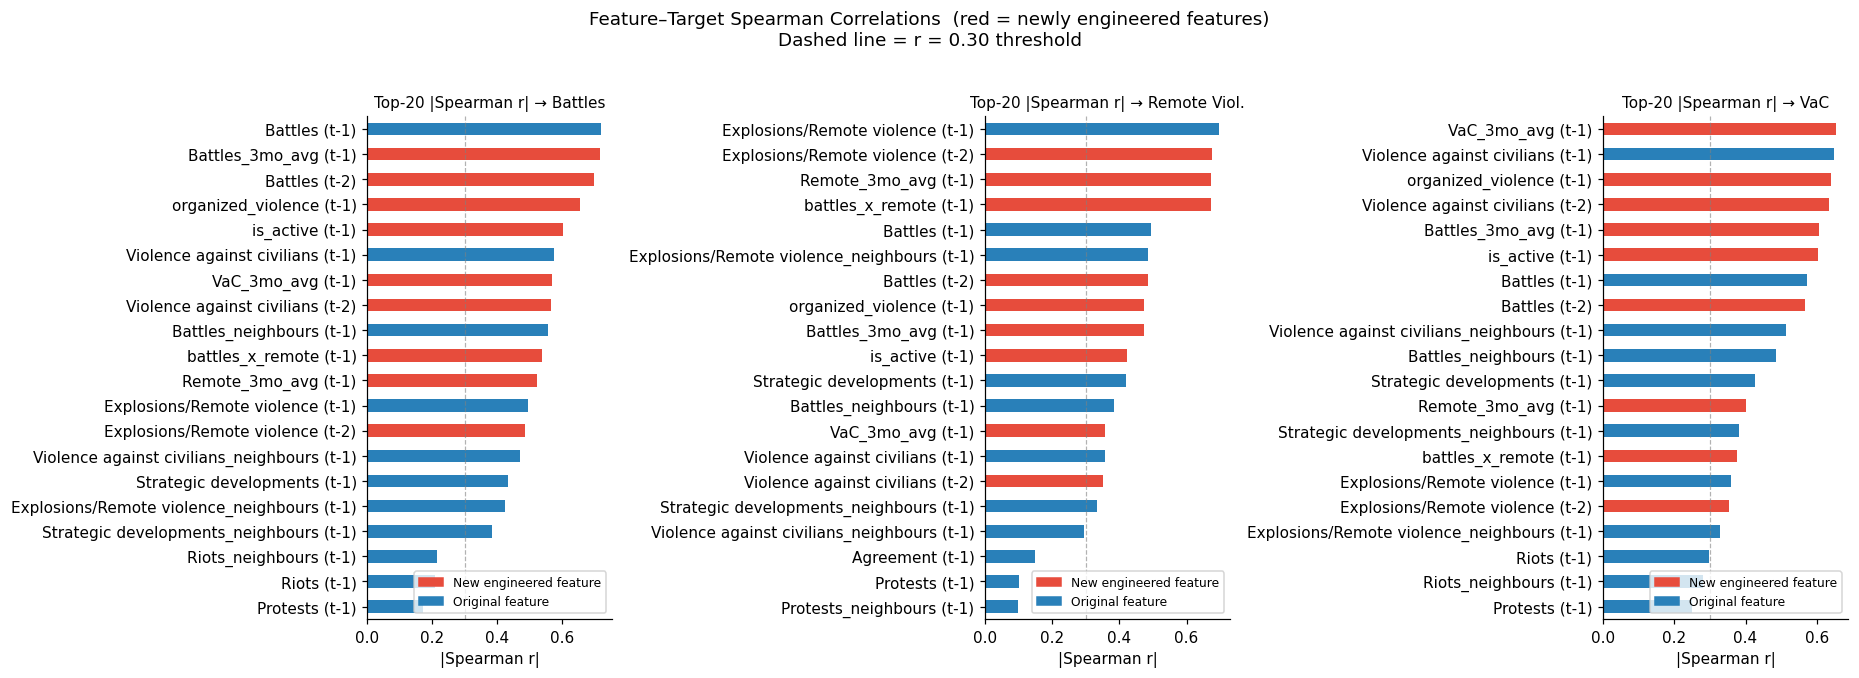

In [3]:
# ── Spearman |r| of every predictor vs each target — highlight new features ──
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for ax, target in zip(axes, TARGETS):
    feats  = [c for c in ENHANCED_PREDS if c in enhanced_df.columns and c != 'importance_weight']
    corrs  = [abs(stats.spearmanr(enhanced_df[f].fillna(0), enhanced_df[target])[0]) for f in feats]
    s      = pd.Series(corrs, index=feats).sort_values().tail(20)
    colors = ['#e74c3c' if f in NEW_FEATURES else '#2980b9' for f in s.index]

    s.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
    ax.set_title(f'Top-20 |Spearman r| → {SHORT[target]}', fontsize=10)
    ax.set_xlabel('|Spearman r|')
    ax.axvline(0.3, color='gray', lw=0.8, ls='--', alpha=0.6)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#e74c3c', label='New engineered feature'),
        Patch(color='#2980b9', label='Original feature'),
    ], fontsize=8, loc='lower right')

plt.suptitle(
    'Feature–Target Spearman Correlations  (red = newly engineered features)\n'
    'Dashed line = r = 0.30 threshold',
    y=1.02, fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{FIGURES}/feature_correlations.png', bbox_inches='tight')
plt.show()
plt.close(fig)


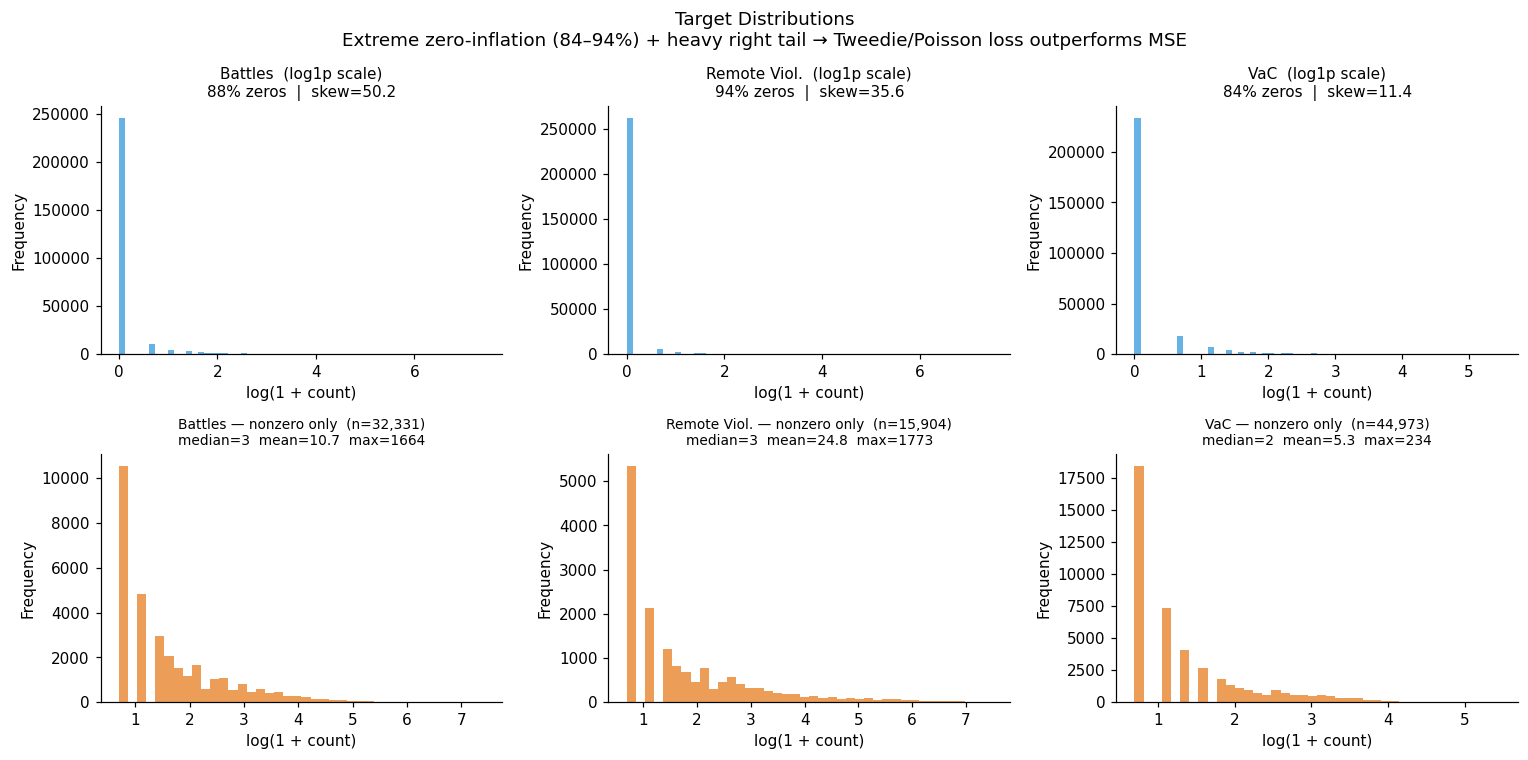

Zero-inflation summary:
  Battles                                        88.4% zeros  skew=50.2  max=1664
  Explosions/Remote violence                     94.3% zeros  skew=35.6  max=1773
  Violence against civilians                     83.9% zeros  skew=11.4  max=234


In [4]:
# ── Target distributions — zero-inflation motivates Tweedie/Poisson loss ─────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for col_idx, (target, short) in enumerate(SHORT.items()):
    vals     = enhanced_df[target]
    nz       = vals[vals > 0]
    zero_pct = (vals == 0).mean() * 100

    ax = axes[0, col_idx]
    ax.hist(np.log1p(vals), bins=60, color='#3498db', alpha=0.75, edgecolor='none')
    ax.set_title(
        f'{short}  (log1p scale)\n{zero_pct:.0f}% zeros  |  skew={stats.skew(vals):.1f}',
        fontsize=10,
    )
    ax.set_xlabel('log(1 + count)')
    ax.set_ylabel('Frequency')

    ax2 = axes[1, col_idx]
    ax2.hist(np.log1p(nz), bins=40, color='#e67e22', alpha=0.75, edgecolor='none')
    ax2.set_title(
        f'{short} — nonzero only  (n={len(nz):,})\n'
        f'median={nz.median():.0f}  mean={nz.mean():.1f}  max={nz.max():.0f}',
        fontsize=9,
    )
    ax2.set_xlabel('log(1 + count)')
    ax2.set_ylabel('Frequency')

plt.suptitle(
    'Target Distributions\n'
    'Extreme zero-inflation (84–94%) + heavy right tail → Tweedie/Poisson loss outperforms MSE',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{FIGURES}/target_distributions.png', bbox_inches='tight')
plt.show()
plt.close(fig)

print('Zero-inflation summary:')
for t in TARGETS:
    v = enhanced_df[t]
    print(f'  {t:45s}  {(v==0).mean():.1%} zeros  skew={stats.skew(v):.1f}  max={v.max():.0f}')


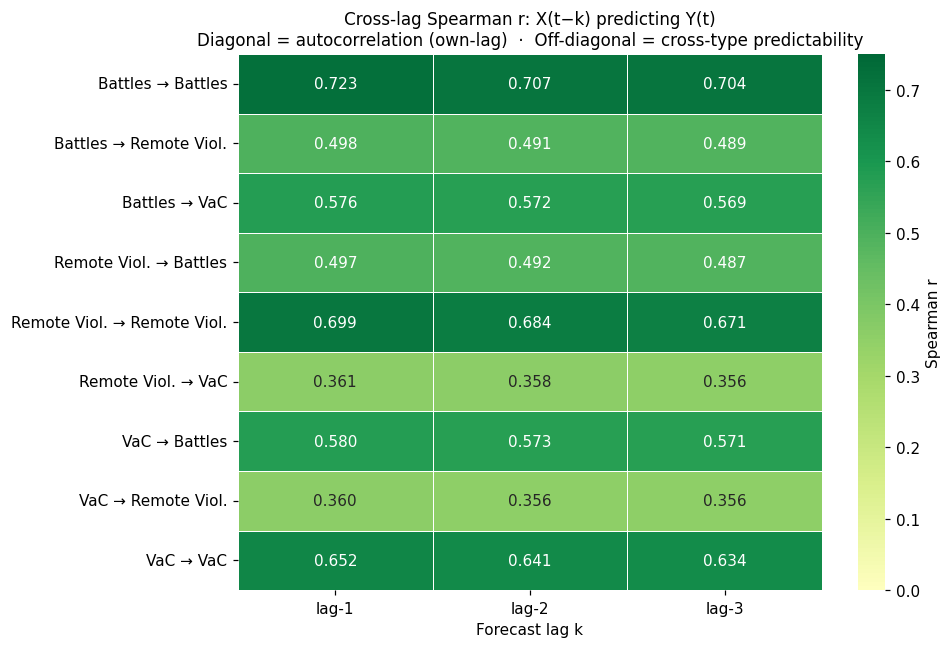

Key findings:
  · Own-lag autocorrelations (diagonal) are highest — persistence dominates
  · Cross-lags are nearly symmetric: B→V ≈ V→B (co-movement, not clear lead/lag)
  · Lag-1→lag-3 barely decays — justifies lag-2 and 3-month rolling avg features
  · E↔V weakest link (0.36): remote violence and civilian targeting are most distinct


In [5]:
# ── Cross-lag Spearman r: X(t-k) predicting Y(t) ─────────────────────────────
df_s  = enhanced_df.sort_values(['matched_admin1_id', 'month_year'])
rows  = {}

for src in TARGETS:
    for tgt in TARGETS:
        key  = f'{SHORT[src]} → {SHORT[tgt]}'
        vals = []
        for lag in [1, 2, 3]:
            shifted = df_s.groupby('matched_admin1_id')[src].shift(lag)
            mask    = shifted.notna()
            r, _    = stats.spearmanr(shifted[mask], df_s[tgt][mask])
            vals.append(round(r, 3))
        rows[key] = vals

hm_df = pd.DataFrame(rows, index=['lag-1', 'lag-2', 'lag-3']).T

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    hm_df, annot=True, fmt='.3f', cmap='RdYlGn',
    center=0, vmin=0, vmax=0.75, ax=ax,
    linewidths=0.5, cbar_kws={'label': 'Spearman r'},
)
ax.set_title(
    'Cross-lag Spearman r: X(t−k) predicting Y(t)\n'
    'Diagonal = autocorrelation (own-lag)  ·  Off-diagonal = cross-type predictability',
    fontsize=11,
)
ax.set_xlabel('Forecast lag k')
plt.tight_layout()
plt.savefig(f'{FIGURES}/cross_lag_heatmap.png', bbox_inches='tight')
plt.show()
plt.close(fig)

print('Key findings:')
print('  · Own-lag autocorrelations (diagonal) are highest — persistence dominates')
print('  · Cross-lags are nearly symmetric: B→V ≈ V→B (co-movement, not clear lead/lag)')
print('  · Lag-1→lag-3 barely decays — justifies lag-2 and 3-month rolling avg features')
print('  · E↔V weakest link (0.36): remote violence and civilian targeting are most distinct')


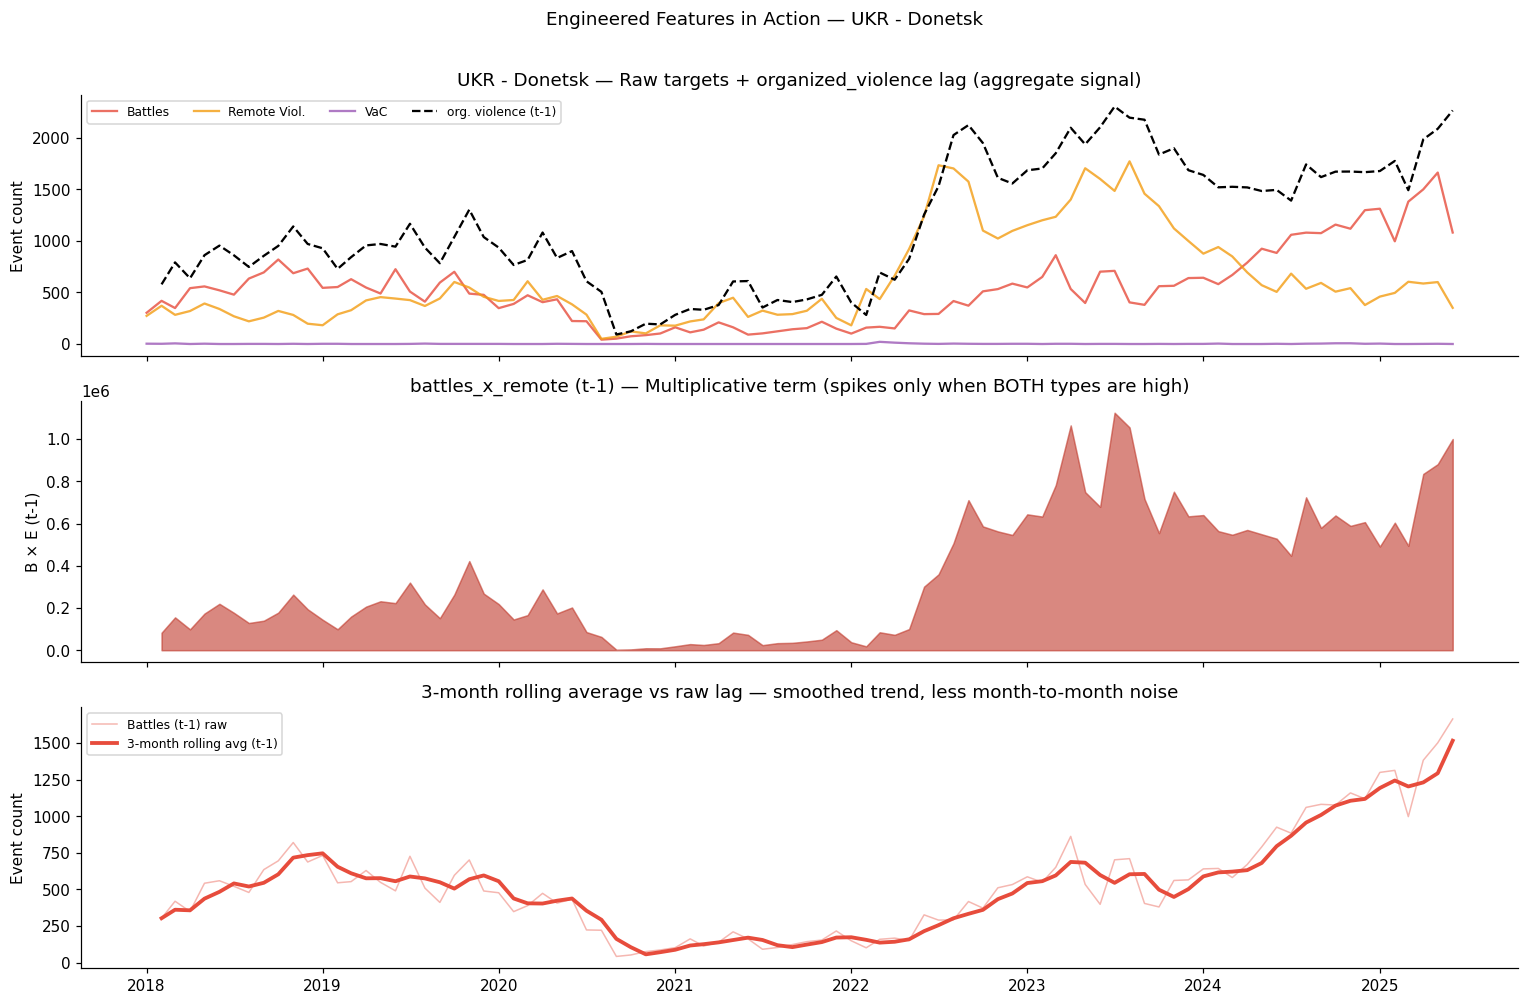

In [6]:
# ── New features visualised on the highest-activity region ───────────────────
region = 'UKR - Donetsk'
rdf    = enhanced_df[enhanced_df['matched_admin1_id'] == region].sort_values('month_year')

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

ax1 = axes[0]
for col, color, label in [
    ('Battles',                    '#e74c3c', 'Battles'),
    ('Explosions/Remote violence', '#f39c12', 'Remote Viol.'),
    ('Violence against civilians', '#9b59b6', 'VaC'),
]:
    ax1.plot(rdf['month_year'], rdf[col], color=color, label=label, alpha=0.8)
ax1.plot(rdf['month_year'], rdf['organized_violence (t-1)'],
         color='black', ls='--', lw=1.5, label='org. violence (t-1)')
ax1.set_title(f'{region} — Raw targets + organized_violence lag (aggregate signal)')
ax1.legend(fontsize=8, ncol=4)
ax1.set_ylabel('Event count')

ax2 = axes[1]
ax2.fill_between(rdf['month_year'], rdf['battles_x_remote (t-1)'], alpha=0.6, color='#c0392b')
ax2.set_title('battles_x_remote (t-1) — Multiplicative term (spikes only when BOTH types are high)')
ax2.set_ylabel('B × E (t-1)')

ax3 = axes[2]
ax3.plot(rdf['month_year'], rdf[B1],
         color='#e74c3c', alpha=0.4, label='Battles (t-1) raw', lw=1)
ax3.plot(rdf['month_year'], rdf['Battles_3mo_avg (t-1)'],
         color='#e74c3c', lw=2.5, label='3-month rolling avg (t-1)')
ax3.set_title('3-month rolling average vs raw lag — smoothed trend, less month-to-month noise')
ax3.set_ylabel('Event count')
ax3.legend(fontsize=8)

plt.suptitle(f'Engineered Features in Action — {region}', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/enhanced_features_example.png', bbox_inches='tight')
plt.show()
plt.close(fig)


## 2. Model Benchmarks

Each model is evaluated on **Main** (31 features) and **Enhanced** (40 features) datasets.

**Test protocol:** top-10 most active regions · last 6 months held out · 3 targets
→ 10 regions × 3 targets = 30 test runs per model per dataset

**Metrics (lower = better):**
- `MAE` — mean absolute error in event counts
- `MAPE%` — mean absolute % error (zero-count months excluded)
- `RMSE` — penalises large misses more heavily than MAE

In [7]:
# ── Top-10 most active regions ───────────────────────────────────────────────
top_10 = (
    main_df.groupby('matched_admin1_id')[TARGETS]
    .sum().sum(axis=1).sort_values(ascending=False)
    .head(10).index.tolist()
)
print('Top 10 most active regions (6-month hold-out test set):')
for i, r in enumerate(top_10, 1):
    print(f'  {i:2d}. {r}')

# ── Dataset registry ─────────────────────────────────────────────────────────
DATASETS = {
    'Main':     (main_df,     settings.predictors),
    'Enhanced': (enhanced_df, ENHANCED_PREDS),
}

accumulated = {ds: [] for ds in DATASETS}   # accumulates results per model
rf_results  = {}                            # RF baseline, used for Δ comparison


# ── Benchmark helpers ────────────────────────────────────────────────────────
def run_model(name, estimator, data, predictors, use_sw=True, scale=False):
    records = []
    for target in TARGETS:
        if target not in data.columns:
            continue
        for region in top_10:
            rdf = (
                data[data['matched_admin1_id'] == region]
                .sort_values('month_year').reset_index(drop=True)
            )
            if len(rdf) < 12:
                continue
            train, test = rdf.iloc[:-6], rdf.iloc[-6:]
            avail = [p for p in predictors if p in train.columns]
            Xtr   = train[avail].fillna(0)
            Xte   = test[avail].fillna(0)
            ytr   = train[target].fillna(0)
            yte   = test[target].fillna(0)
            sw    = train['importance_weight'].fillna(1)

            if scale:
                sc  = StandardScaler()
                Xtr = pd.DataFrame(sc.fit_transform(Xtr), columns=Xtr.columns)
                Xte = pd.DataFrame(sc.transform(Xte),     columns=Xte.columns)

            m = clone(estimator)
            try:
                m.fit(Xtr, ytr, sample_weight=sw) if use_sw else m.fit(Xtr, ytr)
            except TypeError:
                m.fit(Xtr, ytr)

            yp   = np.maximum(m.predict(Xte), 0)   # clip negatives
            mae  = mean_absolute_error(yte, yp)
            rmse = float(np.sqrt(mean_squared_error(yte, yp)))
            nz   = yte != 0
            mape = float(np.mean(np.abs((yte[nz] - yp[nz]) / yte[nz])) * 100) if nz.any() else np.nan
            records.append({
                'model':  name,
                'target': target,
                'region': region,
                'mae':    round(mae,  2),
                'mape':   round(mape, 2) if not np.isnan(mape) else np.nan,
                'rmse':   round(rmse, 2),
            })
    return pd.DataFrame(records)


def show_results(name, res_dict):
    print(f'\n{"="*62}')
    print(f'  {name}')
    print(f'{"="*62}')
    for ds_name, res in res_dict.items():
        tbl = res.groupby('target')[['mae', 'mape', 'rmse']].mean().round(2)
        tbl.columns = [f'{c.upper()} ({ds_name})' for c in tbl.columns]
        mm, mp, mr  = res['mae'].mean(), res['mape'].mean(), res['rmse'].mean()
        line = f'  [{ds_name}]  MAE={mm:.2f}  MAPE={mp:.1f}%  RMSE={mr:.2f}'
        if ds_name in rf_results:
            rf_mae = rf_results[ds_name]['mae'].mean()
            line  += f'   |   Δ vs RF: {(mm - rf_mae) / rf_mae * 100:+.1f}%'
        print(line)
        display(tbl)


MODEL_ORDER   = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LGBM Poisson', 'LGBM Tweedie']
MODEL_COLORS  = {
    'Random Forest':     '#3498db',
    'Gradient Boosting': '#2ecc71',
    'XGBoost':           '#e67e22',
    'LGBM Poisson':      '#9b59b6',
    'LGBM Tweedie':      '#e74c3c',
}


Top 10 most active regions (6-month hold-out test set):
   1. UKR - Donetsk
   2. UKR - Kharkiv
   3. UKR - Sumy
   4. SYR - Idlib
   5. PSX - Gaza
   6. UKR - Kherson
   7. BRA - Rio de Janeiro
   8. SYR - Aleppo
   9. UKR - Zaporizhzhia
  10. UKR - Luhansk


In [8]:
# ═══ Random Forest  [main model — project baseline] ════════════════════════════
_rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

rf_res = {ds: run_model('Random Forest', _rf, data, preds)
          for ds, (data, preds) in DATASETS.items()}

rf_results.update(rf_res)                   # store for Δ computation in later cells
for ds, res in rf_res.items():
    accumulated[ds].append(res)

show_results('Random Forest  [main model — baseline]', rf_res)



  Random Forest  [main model — baseline]
  [Main]  MAE=56.45  MAPE=242.2%  RMSE=66.22   |   Δ vs RF: +0.0%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,55.18,370.13,65.13
Explosions/Remote violence,108.77,218.76,127.38
Violence against civilians,5.41,111.54,6.14


  [Enhanced]  MAE=57.16  MAPE=306.2%  RMSE=66.49   |   Δ vs RF: +0.0%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,53.99,534.77,63.89
Explosions/Remote violence,112.03,222.17,129.42
Violence against civilians,5.44,125.45,6.16


In [9]:
# ═══ LightGBM — Poisson  (natural loss for discrete event counts) ═════════════
# Poisson assumes E[Y] = Var[Y]; good for mild overdispersion
_lgbm_p = LGBMRegressor(
    objective         = 'poisson',
    n_estimators      = 300,
    learning_rate     = 0.05,
    num_leaves        = 63,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

lgbmp_res = {ds: run_model('LGBM Poisson', _lgbm_p, data, preds)
             for ds, (data, preds) in DATASETS.items()}

for ds, res in lgbmp_res.items():
    accumulated[ds].append(res)

show_results('LightGBM — Poisson objective', lgbmp_res)



  LightGBM — Poisson objective
  [Main]  MAE=52.85  MAPE=172.8%  RMSE=64.35   |   Δ vs RF: -6.4%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,51.14,239.20,61.50
Explosions/Remote violence,102.38,169.57,125.88
Violence against civilians,5.02,93.97,5.67


  [Enhanced]  MAE=52.75  MAPE=152.6%  RMSE=62.44   |   Δ vs RF: -7.7%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,48.08,188.51,60.09
Explosions/Remote violence,105.24,168.44,121.72
Violence against civilians,4.92,87.80,5.49


In [10]:
# ═══ LightGBM — Tweedie  [CAST methodology] ═══════════════════════════════════
#
# Tweedie variance power p ∈ (1, 2):
#   p → 1  : Poisson (zero-inflated counts)
#   p = 1.5: compound Poisson-Gamma (CAST default — handles both zeros and heavy tails)
#   p → 2  : Gamma (continuous positive)
#
# Why this works for conflict data:
#   - 84–94% zeros → Tweedie models the spike at 0 probabilistically
#   - skewness 11–50 → log-link squashes the tail
#   - reg_alpha/lambda add L1/L2 regularisation for the sparse predictor matrix

_lgbm_t = LGBMRegressor(
    objective              = 'tweedie',
    tweedie_variance_power = 1.5,
    n_estimators           = 300,
    learning_rate          = 0.05,
    num_leaves             = 63,
    min_child_samples      = 20,
    subsample              = 0.8,
    colsample_bytree       = 0.8,
    reg_alpha              = 0.1,
    reg_lambda             = 1.0,
    random_state           = 42,
    n_jobs                 = -1,
    verbose                = -1,
)

lgbmt_res = {ds: run_model('LGBM Tweedie', _lgbm_t, data, preds)
             for ds, (data, preds) in DATASETS.items()}

for ds, res in lgbmt_res.items():
    accumulated[ds].append(res)

show_results('LightGBM — Tweedie  [CAST methodology]', lgbmt_res)



  LightGBM — Tweedie  [CAST methodology]
  [Main]  MAE=56.69  MAPE=167.5%  RMSE=66.22   |   Δ vs RF: +0.4%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,50.15,232.54,61.06
Explosions/Remote violence,114.80,158.43,131.88
Violence against civilians,5.11,97.43,5.71


  [Enhanced]  MAE=56.17  MAPE=151.5%  RMSE=66.31   |   Δ vs RF: -1.7%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,50.47,187.86,63.85
Explosions/Remote violence,113.19,162.31,129.63
Violence against civilians,4.84,92.39,5.46


In [11]:
# ═══ XGBoost ══════════════════════════════════════════════════════════════════
_xgb = XGBRegressor(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)

xgb_res = {ds: run_model('XGBoost', _xgb, data, preds)
           for ds, (data, preds) in DATASETS.items()}

for ds, res in xgb_res.items():
    accumulated[ds].append(res)

show_results('XGBoost', xgb_res)



  XGBoost
  [Main]  MAE=61.35  MAPE=210.4%  RMSE=70.92   |   Δ vs RF: +8.7%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,54.61,285.83,65.31
Explosions/Remote violence,123.79,201.22,141.21
Violence against civilians,5.65,127.63,6.25


  [Enhanced]  MAE=57.67  MAPE=198.9%  RMSE=67.32   |   Δ vs RF: +0.9%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,48.37,258.48,58.91
Explosions/Remote violence,118.87,203.91,136.66
Violence against civilians,5.76,118.25,6.38


In [12]:
# ═══ Gradient Boosting (sklearn) ══════════════════════════════════════════════
_gbr = GradientBoostingRegressor(
    n_estimators  = 200,
    learning_rate = 0.05,
    max_depth     = 4,
    subsample     = 0.8,
    random_state  = 42,
)

gbr_res = {ds: run_model('Gradient Boosting', _gbr, data, preds)
           for ds, (data, preds) in DATASETS.items()}

for ds, res in gbr_res.items():
    accumulated[ds].append(res)

show_results('Gradient Boosting', gbr_res)



  Gradient Boosting
  [Main]  MAE=59.57  MAPE=300.2%  RMSE=68.73   |   Δ vs RF: +5.5%


,MAE (Main),MAPE (Main),RMSE (Main)
target,,,
Battles,57.81,528.37,68.36
Explosions/Remote violence,114.57,218.07,130.72
Violence against civilians,6.33,117.53,7.11


  [Enhanced]  MAE=61.07  MAPE=408.3%  RMSE=70.37   |   Δ vs RF: +6.9%


,MAE (Enhanced),MAPE (Enhanced),RMSE (Enhanced)
target,,,
Battles,59.44,794.97,69.37
Explosions/Remote violence,117.50,235.76,134.69
Violence against civilians,6.28,140.67,7.06


## 3. Summary

Overall ranking tables, bar charts, and LGBM Tweedie feature importances — showing which of the new engineered features the best model actually relies on.

In [13]:
# ── Ranked summary table per dataset ─────────────────────────────────────────
for ds_name in DATASETS:
    combined  = pd.concat(accumulated[ds_name], ignore_index=True)
    rf_mae    = rf_results[ds_name]['mae'].mean()
    available = [m for m in MODEL_ORDER if m in combined['model'].unique()]

    summary = (
        combined.groupby('model')[['mae', 'mape', 'rmse']]
        .mean().round(2)
        .reindex(available)
        .rename(columns={'mae': 'MAE', 'mape': 'MAPE%', 'rmse': 'RMSE'})
    )
    summary['Δ MAE vs RF (%)'] = ((summary['MAE'] - rf_mae) / rf_mae * 100).round(1)

    print(f'\n{"═" * 58}')
    print(f'  {ds_name.upper()} DATASET — avg: top-10 regions × 3 targets')
    print(f'{"═" * 58}')
    display(
        summary.style
        .background_gradient(subset=['MAE'],  cmap='RdYlGn_r',
                             vmin=summary['MAE'].min() * 0.9, vmax=summary['MAE'].max() * 1.1)
        .background_gradient(subset=['Δ MAE vs RF (%)'], cmap='RdYlGn_r', vmin=-25, vmax=25)
        .format({'MAE': '{:.2f}', 'MAPE%': '{:.1f}', 'RMSE': '{:.2f}',
                 'Δ MAE vs RF (%)': '{:+.1f}%'})
    )



══════════════════════════════════════════════════════════
  MAIN DATASET — avg: top-10 regions × 3 targets
══════════════════════════════════════════════════════════


,MAE,MAPE%,RMSE,Δ MAE vs RF (%)
model,,,,
Random Forest,56.45,242.2,66.22,-0.0%
Gradient Boosting,59.57,300.2,68.73,+5.5%
XGBoost,61.35,210.4,70.92,+8.7%
LGBM Poisson,52.84,172.8,64.35,-6.4%
LGBM Tweedie,56.69,167.5,66.22,+0.4%



══════════════════════════════════════════════════════════
  ENHANCED DATASET — avg: top-10 regions × 3 targets
══════════════════════════════════════════════════════════


,MAE,MAPE%,RMSE,Δ MAE vs RF (%)
model,,,,
Random Forest,57.16,306.2,66.49,+0.0%
Gradient Boosting,61.07,408.3,70.37,+6.8%
XGBoost,57.67,198.9,67.32,+0.9%
LGBM Poisson,52.75,152.6,62.44,-7.7%
LGBM Tweedie,56.17,151.5,66.31,-1.7%


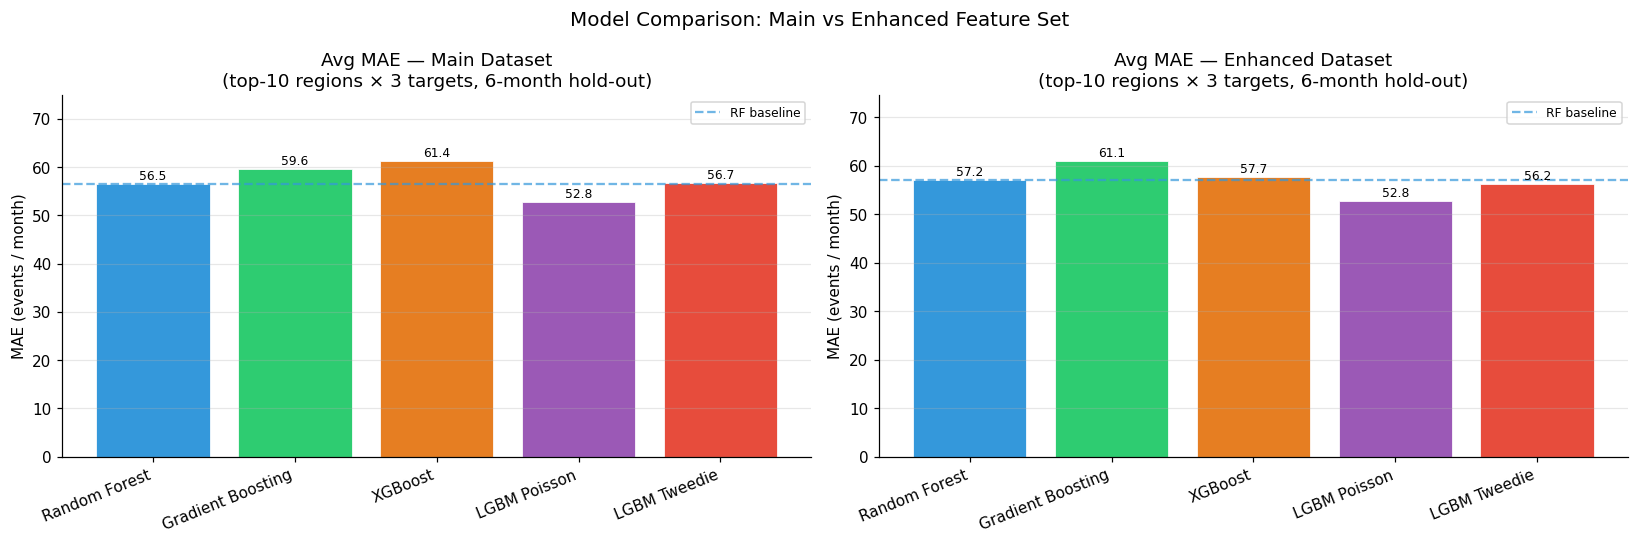

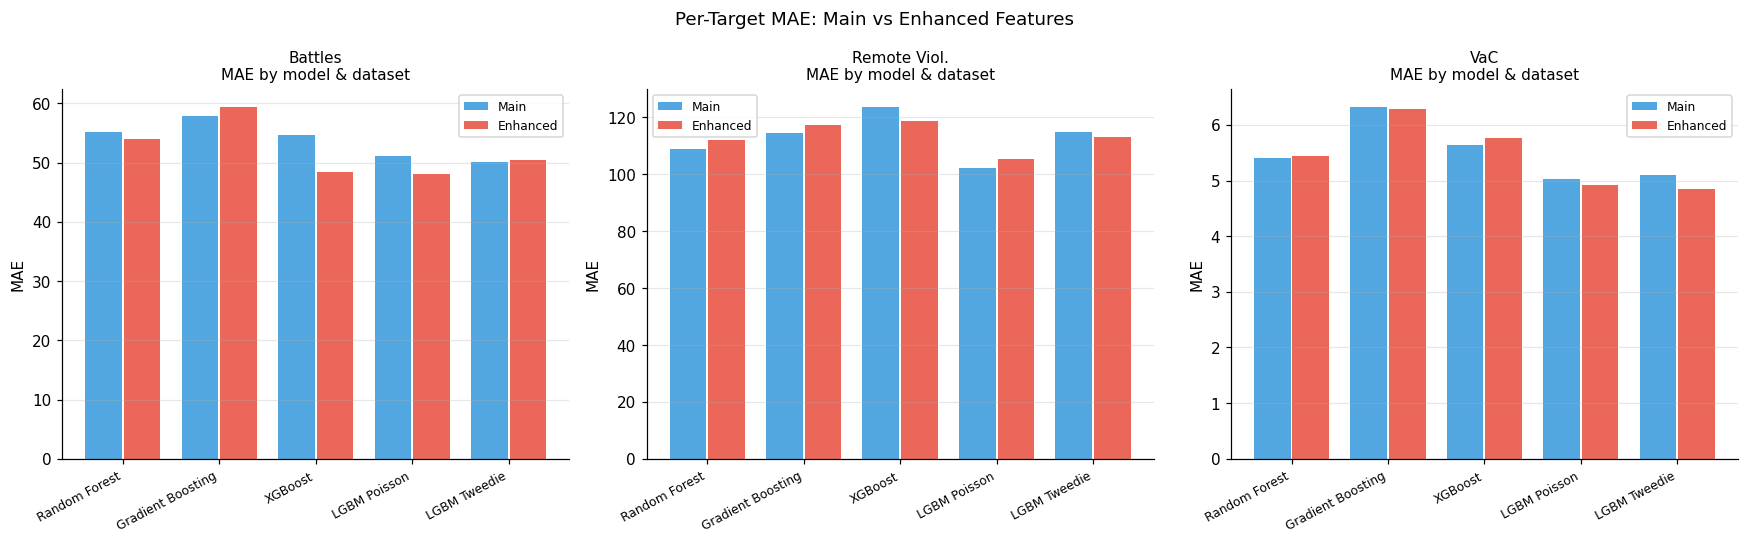

In [14]:
# ── Overall MAE: Main vs Enhanced ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, ds_name in zip(axes, DATASETS):
    combined  = pd.concat(accumulated[ds_name], ignore_index=True)
    available = [m for m in MODEL_ORDER if m in combined['model'].unique()]
    mae_vals  = [combined[combined['model'] == m]['mae'].mean() for m in available]
    bars      = ax.bar(
        available, mae_vals,
        color=[MODEL_COLORS.get(m, '#95a5a6') for m in available],
        edgecolor='white', linewidth=0.5,
    )
    ax.axhline(rf_results[ds_name]['mae'].mean(),
               color='#3498db', lw=1.5, ls='--', alpha=0.7, label='RF baseline')
    for bar, val in zip(bars, mae_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(
        f'Avg MAE — {ds_name} Dataset\n'
        f'(top-10 regions × 3 targets, 6-month hold-out)'
    )
    ax.set_ylabel('MAE (events / month)')
    ax.set_xticklabels(available, rotation=22, ha='right')
    ax.legend(fontsize=8)
    ax.set_ylim(0, max(mae_vals) * 1.22)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison: Main vs Enhanced Feature Set', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGURES}/model_comparison.png', bbox_inches='tight')
plt.show()
plt.close(fig)

# ── Per-target breakdown ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ds_colors = {'Main': '#3498db', 'Enhanced': '#e74c3c'}

for ax, target in zip(axes, TARGETS):
    for i, (ds_name, (data, preds)) in enumerate(DATASETS.items()):
        combined  = pd.concat(accumulated[ds_name], ignore_index=True)
        sub       = combined[combined['target'] == target]
        available = [m for m in MODEL_ORDER if m in sub['model'].unique()]
        mae_vals  = [sub[sub['model'] == m]['mae'].mean() for m in available]
        offset    = -0.2 + 0.4 * i
        ax.bar(np.arange(len(available)) + offset, mae_vals, 0.38,
               label=ds_name, color=ds_colors[ds_name], alpha=0.85)
    ax.set_xticks(range(len(MODEL_ORDER)))
    ax.set_xticklabels(MODEL_ORDER, rotation=28, ha='right', fontsize=8)
    ax.set_title(f'{SHORT[target]}\nMAE by model & dataset', fontsize=10)
    ax.set_ylabel('MAE')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Per-Target MAE: Main vs Enhanced Features', fontsize=12)
plt.tight_layout()
plt.savefig(f'{FIGURES}/per_target_comparison.png', bbox_inches='tight')
plt.show()
plt.close(fig)


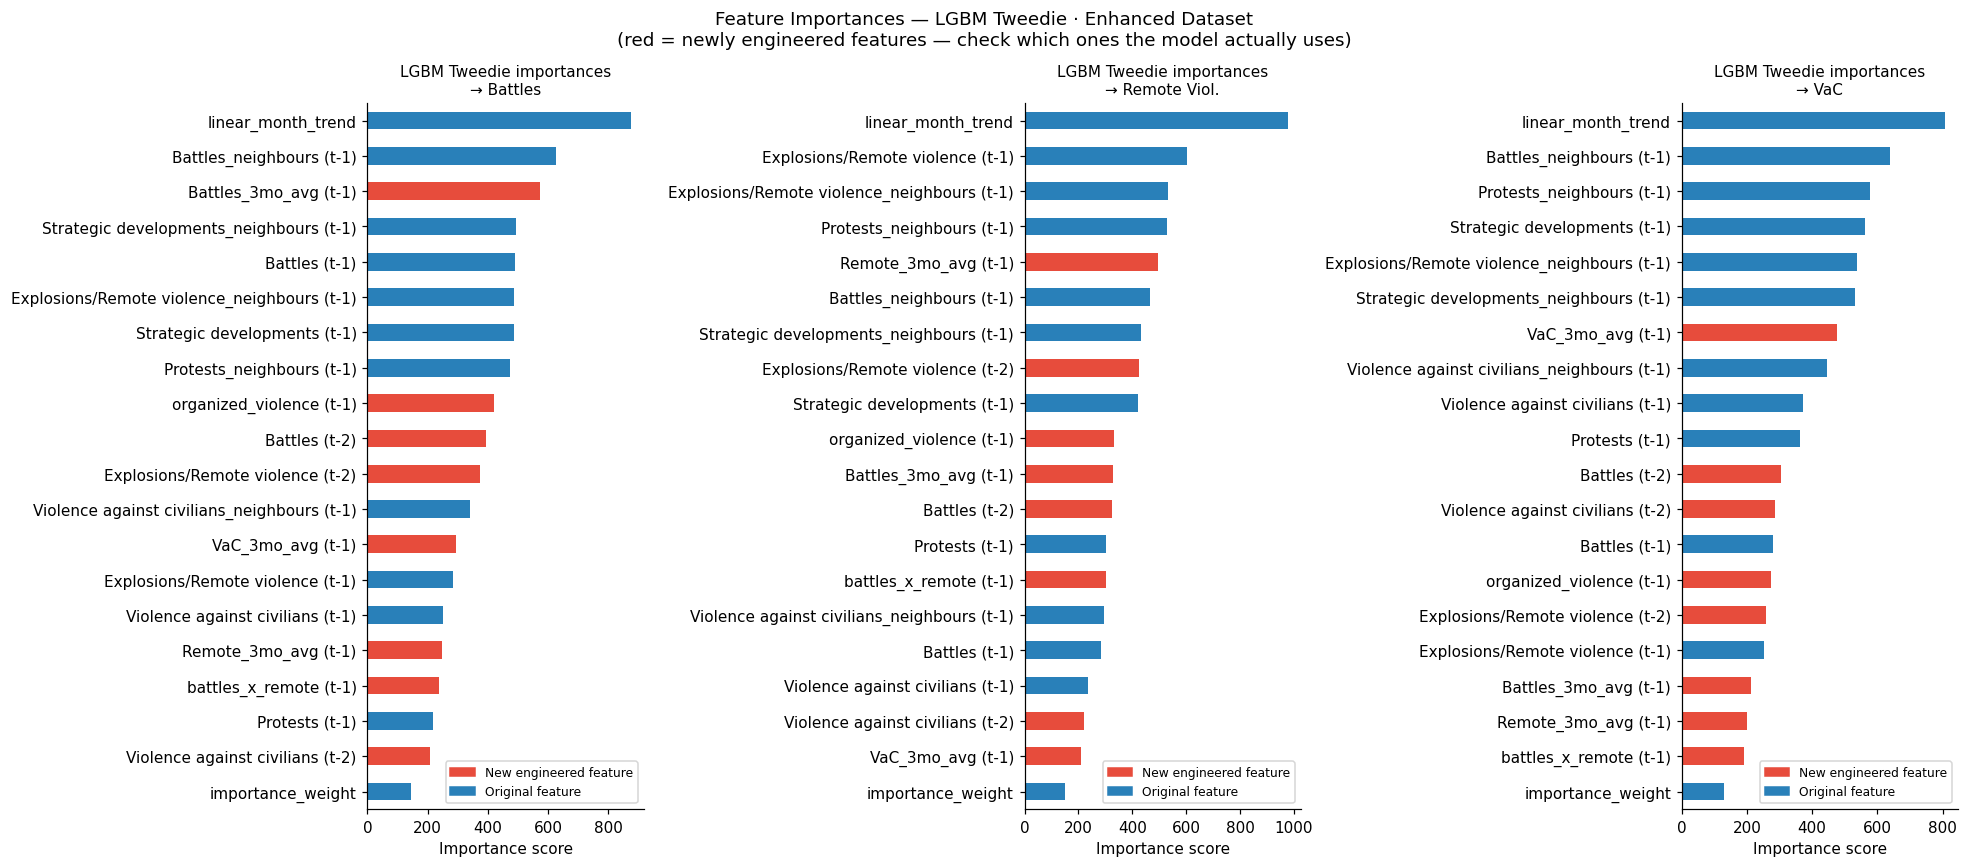

In [15]:
# ── Feature importances — LGBM Tweedie trained on all top-10 combined ─────────
_fi = LGBMRegressor(
    objective='tweedie', tweedie_variance_power=1.5,
    n_estimators=300, learning_rate=0.05, num_leaves=63,
    min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    random_state=42, n_jobs=-1, verbose=-1,
)
avail_preds = [p for p in ENHANCED_PREDS if p in enhanced_df.columns]

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for ax, target in zip(axes, TARGETS):
    pool  = (enhanced_df[enhanced_df['matched_admin1_id'].isin(top_10)]
             .sort_values('month_year'))
    train = pool.iloc[:int(len(pool) * 0.85)]
    Xtr   = train[avail_preds].fillna(0)
    ytr   = train[target].fillna(0)
    sw    = train['importance_weight'].fillna(1)

    m = clone(_fi)
    m.fit(Xtr, ytr, sample_weight=sw)

    imp    = pd.Series(m.feature_importances_, index=Xtr.columns)
    imp    = imp[imp > 0].sort_values().tail(20)
    colors = ['#e74c3c' if f in NEW_FEATURES else '#2980b9' for f in imp.index]

    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='none')
    ax.set_title(f'LGBM Tweedie importances\n→ {SHORT[target]}', fontsize=10)
    ax.set_xlabel('Importance score')

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color='#e74c3c', label='New engineered feature'),
        Patch(color='#2980b9', label='Original feature'),
    ], fontsize=8)

plt.suptitle(
    'Feature Importances — LGBM Tweedie · Enhanced Dataset\n'
    '(red = newly engineered features — check which ones the model actually uses)',
    fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{FIGURES}/feature_importance_lgbm.png', bbox_inches='tight')
plt.show()
plt.close(fig)
